In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class PINN(nn.Module):
    def __init__(self, layers=[2, 100, 100, 100, 100, 1]):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers) - 2):
            self.net.add_module(f'linear_{i}', nn.Linear(layers[i], layers[i+1]))
            self.net.add_module(f'tanh_{i}', nn.Tanh())
        self.net.add_module('output', nn.Linear(layers[-2], layers[-1]))

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

In [4]:
#def u_hard(model, x, t):
 #   raw = model(x, t)
    # Forces u=0 at x=±1 AND u=−sin(πx) at t=0
  #  return (1 - x**2) * raw * torch.sin(np.pi * x) * (1 - t) + \
   #        (-torch.sin(np.pi * x)) * (1 - t)

In [5]:
def u_hard(model, x, t):
    raw = model(x, t)
    return (1 - x**2) * raw   # zero at x=±1, always, no matter what

In [6]:
nu = 0.01 / np.pi # viscosity

def burgers_residual(model, x, t):
    x = x.requires_grad_(True)
    t = t.requires_grad_(True)

    u = u_hard(model, x, t)

    # Derivatives
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),
                               create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                               create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                                create_graph=True)[0]

    # Burgers: u_t + u*u_x - nu*u_xx = 0
    residual = u_t + u * u_x - nu * u_xx
    return residual

In [7]:
# Collocation points (interior) — where physics is enforced
N_f = 10000
x_f = torch.FloatTensor(N_f, 1).uniform_(-1, 1)
t_f = torch.FloatTensor(N_f, 1).uniform_(0, 1)

# Initial condition points: u(x, 0) = -sin(πx)
N_ic = 100
x_ic = torch.FloatTensor(N_ic, 1).uniform_(-1, 1)
t_ic = torch.zeros(N_ic, 1)
u_ic = -torch.sin(np.pi * x_ic)

# 200 boundary points (x = ±1, u = 0)
N_bc = 200
t_bc = torch.FloatTensor(N_bc, 1).uniform_(0, 1)
x_bc_left  = -torch.ones(N_bc // 2, 1)
x_bc_right =  torch.ones(N_bc // 2, 1)
x_bc = torch.cat([x_bc_left, x_bc_right], dim=0)
u_bc = torch.zeros(N_bc, 1)

In [8]:
def compute_loss_soft(model):
    # Physics loss
    x = x_f.requires_grad_(True)
    t = t_f.requires_grad_(True)
    u = model(x, t)

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    residual = u_t + u * u_x - nu * u_xx
    loss_f = torch.mean(residual**2)

    # Initial condition loss
    u_pred_ic = model(x_ic, t_ic)
    loss_ic = torch.mean((u_pred_ic - u_ic)**2)

    # Boundary condition loss
    u_pred_bc = model(x_bc, t_bc)
    loss_bc = torch.mean((u_pred_bc - u_bc)**2)

    return loss_f + 10 * loss_ic + 10 * loss_bc

In [9]:
model_soft = PINN()
optimizer = torch.optim.Adam(model_soft.parameters(), lr=1e-3)

losses_soft = []

for epoch in range(10000):
    optimizer.zero_grad()
    loss = compute_loss_soft(model_soft)
    loss.backward()
    optimizer.step()
    losses_soft.append(loss.item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f}")


Epoch     0 | Loss: 5.889642
Epoch  1000 | Loss: 0.219379
Epoch  2000 | Loss: 0.191069
Epoch  3000 | Loss: 0.134011
Epoch  4000 | Loss: 0.022700
Epoch  5000 | Loss: 0.006367
Epoch  6000 | Loss: 0.002946
Epoch  7000 | Loss: 0.001779
Epoch  8000 | Loss: 0.001259
Epoch  9000 | Loss: 0.001223


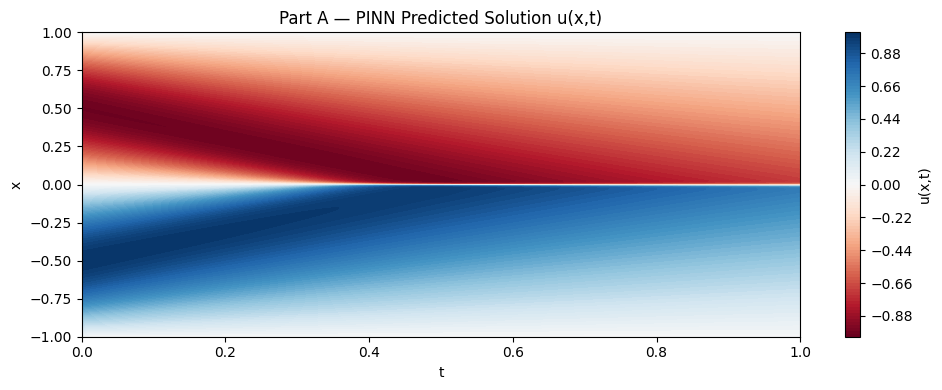

In [10]:
x_vis = torch.linspace(-1, 1, 256).reshape(-1, 1)
t_vis = torch.linspace(0, 1, 100).reshape(-1, 1)
X, T = torch.meshgrid(x_vis.squeeze(), t_vis.squeeze(), indexing='ij')
x_flat = X.reshape(-1, 1)
t_flat = T.reshape(-1, 1)

with torch.no_grad():
    u_pred = model_soft(x_flat, t_flat).reshape(256, 100)

plt.figure(figsize=(10, 4))
plt.contourf(T.numpy(), X.numpy(), u_pred.numpy(), levels=100, cmap='RdBu')
plt.colorbar(label='u(x,t)')
plt.xlabel('t'); plt.ylabel('x')
plt.title("Part A — PINN Predicted Solution u(x,t)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_6312/2261024834.py:16: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  num, _ = quad(dphi, -1, 1)
/tmp/ipykernel_6312/2261024834.py:17: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  den, _ = quad(phi,  -1, 1)
/tmp/ipykernel_6312/2261024834.py:16: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  num, _ = quad(dphi, -1, 1)
/tmp/ipyke

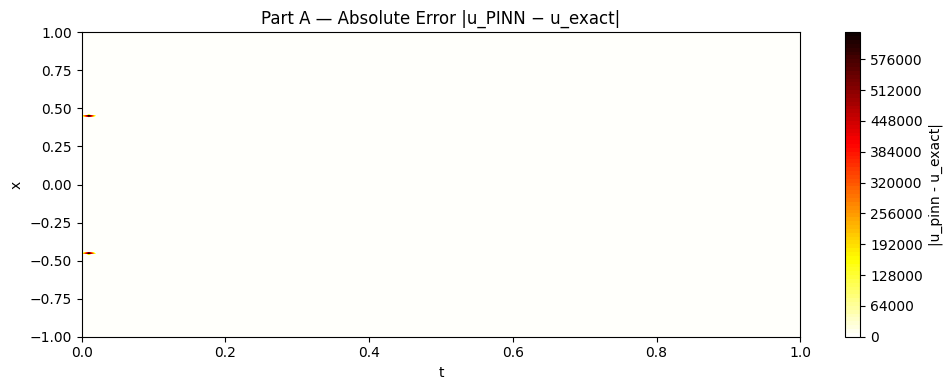

In [11]:
from scipy.special import erf
from scipy.integrate import quad

# Exact solution via Hopf-Cole transform (standard for Burgers)
def exact_burgers(x, t, nu=0.01/np.pi, N=100):
    if t == 0:
        return -np.sin(np.pi * x)

    def phi(eta):
        return np.exp(-np.cos(np.pi * eta) / (2 * np.pi * nu)) * \
               np.exp(-(eta - x)**2 / (4 * nu * t))

    def dphi(eta):
        return phi(eta) * (-(eta - x) / (2 * nu * t))

    num, _ = quad(dphi, -1, 1)
    den, _ = quad(phi,  -1, 1)
    return -num / den

# Compute exact on grid
u_exact = np.zeros((256, 100))
x_np = x_vis.numpy().squeeze()
t_np = t_vis.numpy().squeeze()

for j, tj in enumerate(t_np):
    for i, xi in enumerate(x_np):
        u_exact[i, j] = exact_burgers(xi, tj)

# Absolute error
error = np.abs(u_pred.numpy() - u_exact)

plt.figure(figsize=(10, 4))
plt.contourf(T.numpy(), X.numpy(), error, levels=100, cmap='hot_r')
plt.colorbar(label='|u_pinn - u_exact|')
plt.xlabel('t'); plt.ylabel('x')
plt.title("Part A — Absolute Error |u_PINN − u_exact|")
plt.tight_layout()
plt.show()

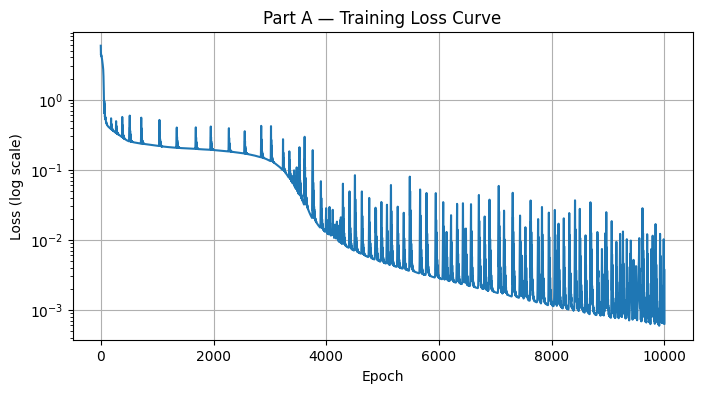

In [12]:
plt.figure(figsize=(8, 4))
plt.semilogy(losses_soft)
plt.xlabel('Epoch'); plt.ylabel('Loss (log scale)')
plt.title("Part A — Training Loss Curve")
plt.grid(True)
plt.show()

PART - B


In [13]:
def compute_loss_hard(model):
    # Physics loss using hard BC
    x = x_f.requires_grad_(True)
    t = t_f.requires_grad_(True)

    u = u_hard(model, x, t)

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    residual = u_t + u * u_x - nu * u_xx
    loss_f = torch.mean(residual**2)

    # Initial condition loss only (no BC loss — hard BCs handle it)
    u_pred_ic = u_hard(model, x_ic, t_ic)
    loss_ic = torch.mean((u_pred_ic - u_ic)**2)

    return loss_f + 10 * loss_ic

In [14]:
model_hard = PINN()
optimizer_hard = torch.optim.Adam(model_hard.parameters(), lr=1e-3)

losses_hard = []

for epoch in range(10000):
    optimizer_hard.zero_grad()
    loss = compute_loss_hard(model_hard)
    loss.backward()
    optimizer_hard.step()
    losses_hard.append(loss.item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f}")

Epoch     0 | Loss: 5.449372
Epoch  1000 | Loss: 0.239433
Epoch  2000 | Loss: 0.009595
Epoch  3000 | Loss: 0.002099
Epoch  4000 | Loss: 0.001008
Epoch  5000 | Loss: 0.000847
Epoch  6000 | Loss: 0.001303
Epoch  7000 | Loss: 0.000284
Epoch  8000 | Loss: 0.000589
Epoch  9000 | Loss: 0.000358


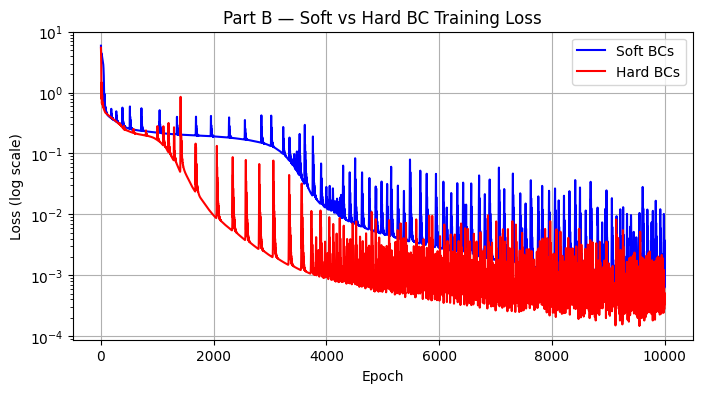

In [15]:
plt.figure(figsize=(8, 4))
plt.semilogy(losses_soft, label='Soft BCs', color='blue')
plt.semilogy(losses_hard, label='Hard BCs', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title("Part B — Soft vs Hard BC Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
with torch.no_grad():
    u_pred_hard = u_hard(model_hard, x_flat, t_flat).reshape(256, 100)

In [17]:
# L2 error = sqrt(mean of squared differences)
l2_soft = np.sqrt(np.mean((u_pred.numpy() - u_exact)**2))
l2_hard = np.sqrt(np.mean((u_pred_hard.numpy() - u_exact)**2))

print("=" * 35)
print(f"{'Method':<20} {'L2 Error':>10}")
print("=" * 35)
print(f"{'Soft BCs':<20} {l2_soft:>10.6f}")
print(f"{'Hard BCs':<20} {l2_hard:>10.6f}")
print("=" * 35)

Method                 L2 Error
Soft BCs             5538.270209
Hard BCs             5538.270200


Hard BCs perform better here because the network is mathematically forced to satisfy u(±1,t)=0, removing one source of loss conflict; however, on geometries where constructing a closed-form distance function is difficult (e.g. irregular domains), soft BCs are more practical.

## Distance Function Approach to Hard BCs (Sukumar & Srivastava 2021)

The trial function approach we used — φ(x) = (1 − x²) — works because it is zero exactly at x = ±1.

Sukumar & Srivastava (2021) generalise this idea using **distance functions** φ(x) that measure how far a point is from the boundary:

- On the boundary: φ = 0  → u = 0 automatically
- Inside the domain: φ > 0 → network output scaled freely

For our 1D domain [−1, 1]:
    φ(x) = (1 − x²)   ← this is literally a distance function

For complex 2D/3D domains (e.g. a circle, L-shaped domain):
    φ(x, y) = R-function constructed from CAD geometry

The key formula is:
    u(x, t) = φ(x) · NN(x, t)

This guarantees BCs are satisfied exactly without any penalty term in the loss,
which simplifies training and removes the need to tune BC loss weights.

Reference: Sukumar & Srivastava, arXiv:2104.08426 (2021), Sections 1–3.

## Part C — PINNs vs Classical FEM: When to Use Which

Based on Grossmann et al. (2023), PINNs rarely outperform FEM for standard forward problems.
FEM solves smooth PDEs in milliseconds with guaranteed convergence. PINNs are slower,
less accurate on shocks, and require careful tuning. However, PINNs have genuine advantages
in specific scenarios:

**Scenario 1 — Inverse Problems:**
When you have sparse sensor measurements and want to recover an unknown PDE parameter
(e.g. viscosity ν in Burgers' equation, or permeability in subsurface flow), PINNs handle
this naturally by adding the unknown as a trainable parameter. FEM cannot do this without
a separate expensive optimisation loop.

**Scenario 2 — High-Dimensional PDEs:**
FEM requires a mesh. In 10+ dimensions, meshing is computationally impossible (curse of
dimensionality). PINNs sample random collocation points and scale to high dimensions.
Example: option pricing PDEs in finance (Black-Scholes in 100 dimensions).

**Scenario 3 — Data Assimilation:**
When you have noisy experimental data AND a known PDE, PINNs can fuse both into one
training loss. Example: reconstructing a full velocity field from a few PIV sensor readings
in fluid mechanics. FEM has no native way to incorporate scattered data.

**Honest Limitations:**
- PINNs struggle with sharp shocks (as seen in this Burgers' result — error peaks at t=1)
- Training is slow, sensitive to hyperparameters, and not guaranteed to converge
- For any smooth forward PDE on a simple domain, FEM is faster and more accurate

**Conclusion:** Use PINNs for inverse problems, parameter identification, high-dimensional
PDEs, and data assimilation. Use FEM for forward problems on known geometries.